### LAB ASSIGNMENT: K-Means Clustering for Customer Segmentation

Problem Statement\
Use the K-Means clustering algorithm to segment customers based on their financial and demographic features.

- Apply both Euclidean and Manhattan distances.

- Visualize results in 2D and 3D to interpret cluster patterns.

#### Importing Libraries and Loading dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score

In [2]:
# Loading the dataset

df = pd.read_csv("Datasets/Cust_Segmentation.csv")

#### Exploratory Data Analysis (EDA)

In [3]:
# Preview the data

df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [4]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The dataset has 850 rows and 10 columns


In [5]:
df.shape 

(850, 10)

In [6]:
# Summary of dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


In [7]:
df.describe()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.00000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000,850.000000
mean,425.50000,35.029412,1.710588,8.565882,46.675294,1.576820,3.078773,0.261429,10.171647
std,245.51816,8.041432,0.927784,6.777884,38.543054,2.125843,3.398799,0.439727,6.719441
min,1.00000,20.000000,1.000000,0.000000,13.000000,0.012000,0.046000,0.000000,0.100000
25%,213.25000,29.000000,1.000000,3.000000,24.000000,0.382500,1.045750,0.000000,5.100000
50%,425.50000,34.000000,1.000000,7.000000,35.000000,0.885000,2.003000,0.000000,8.700000
75%,637.75000,41.000000,2.000000,13.000000,55.750000,1.898500,3.903250,1.000000,13.800000
max,850.00000,56.000000,5.000000,33.000000,446.000000,20.561000,35.197000,1.000000,41.300000


In [8]:
df.isnull().sum()

Customer Id          0
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
Address              0
DebtIncomeRatio      0
dtype: int64

#### Data Cleaning & Feature Selection

In [9]:
# Dropping non-useful or missing-heavy columns
df_cluster = df.drop(['Customer Id', 'Address', 'Defaulted'], axis=1)

In [10]:
# remaining features
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              850 non-null    int64  
 1   Edu              850 non-null    int64  
 2   Years Employed   850 non-null    int64  
 3   Income           850 non-null    int64  
 4   Card Debt        850 non-null    float64
 5   Other Debt       850 non-null    float64
 6   DebtIncomeRatio  850 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 46.6 KB


In [11]:
# Feature Scaling
scaler = StandardScaler()

In [12]:
X_scaled = scaler.fit_transform(df_cluster)

In [13]:
pd.DataFrame(X_scaled, columns=df_cluster.columns).head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,DebtIncomeRatio
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.576525
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,0.391387
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.597554
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.576525
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.442507


#### K-Means Clustering - Euclidean Distance

In [14]:
#Applying KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels_euclidean = kmeans.fit_predict(X_scaled)

In [15]:
df['Cluster_Euc'] = labels_euclidean

In [16]:
df['Cluster_Euc'].value_counts()

Cluster_Euc
1    466
0    282
2    102
Name: count, dtype: int64

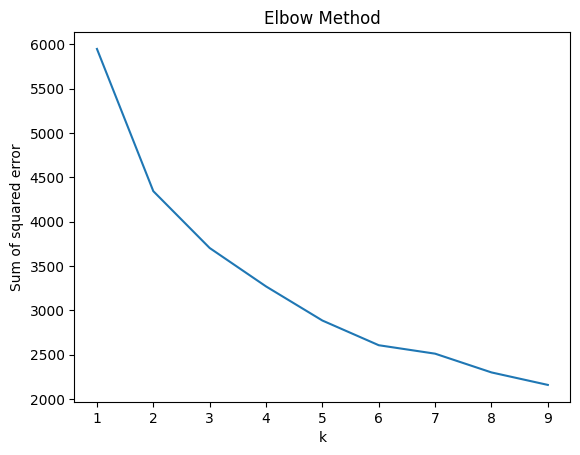

In [17]:
errors = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    errors.append(km.inertia_)

plt.plot(range(1, 10), errors)
plt.xlabel('k')
plt.ylabel('Sum of squared error')
plt.title('Elbow Method')
plt.show()

The Elbow Method confirms that 3 clusters is a reasonable choice for this dataset — beyond that, the improvement in cluster tightness diminishes.

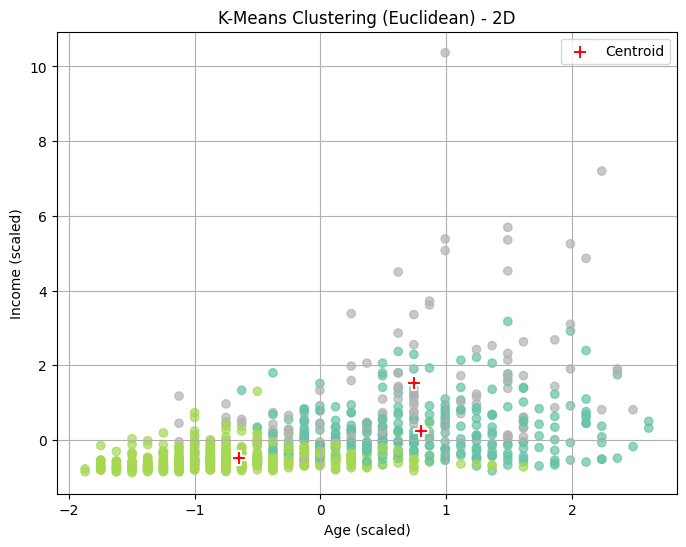

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=labels_euclidean, cmap='Set2', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 3],
            c='red', s=100, marker='P', edgecolors='white', linewidths=1.5, label='Centroid')
plt.title("K-Means Clustering (Euclidean) - 2D")
plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")
plt.legend()
plt.grid(True)
plt.show()

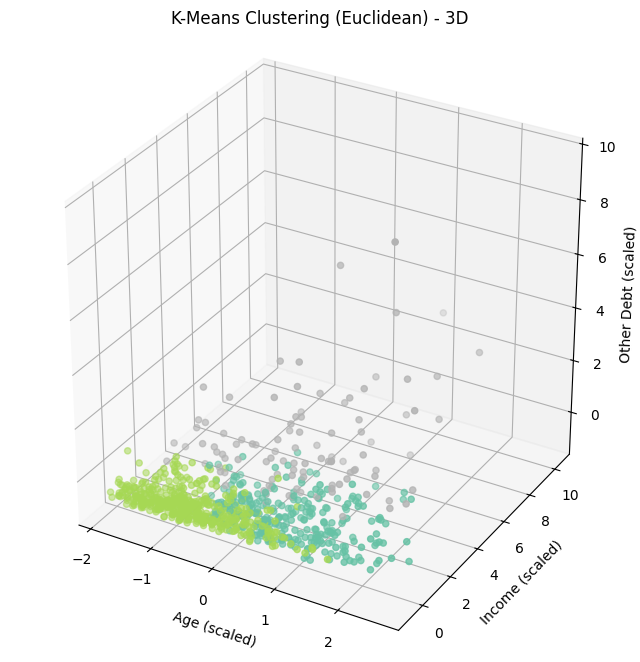

In [30]:
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_scaled[:, 0], X_scaled[:, 3], X_scaled[:, 5], 
           c=labels_euclidean, cmap='Set2')
ax.set_title("K-Means Clustering (Euclidean) - 3D")
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Income (scaled)")
ax.set_zlabel("Other Debt (scaled)")
ax.set_box_aspect([1, 1, 1])
plt.show()

In [20]:
score = silhouette_score(X_scaled, labels_euclidean)
print("Silhouette Score (Euclidean):", score)

Silhouette Score (Euclidean): 0.2172394086659741


#### K-Means Clustering - Manhattan Distance

In [21]:
def kmeans_manhattan_scipy(X, k=3, max_iters=100):
    np.random.seed(42)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Compute Manhattan distances to centroids
        distances = cdist(X, centroids, metric='cityblock')
        labels = np.argmin(distances, axis=1)

        # Update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        # Break if centroids don't change
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return labels, centroids

In [22]:
labels_manhattan, centroids_manhattan = kmeans_manhattan_scipy(X_scaled, k=3)

In [23]:
df['Cluster_Man'] = labels_manhattan

In [24]:
df['Cluster_Man'].value_counts()

Cluster_Man
0    607
1    148
2     95
Name: count, dtype: int64

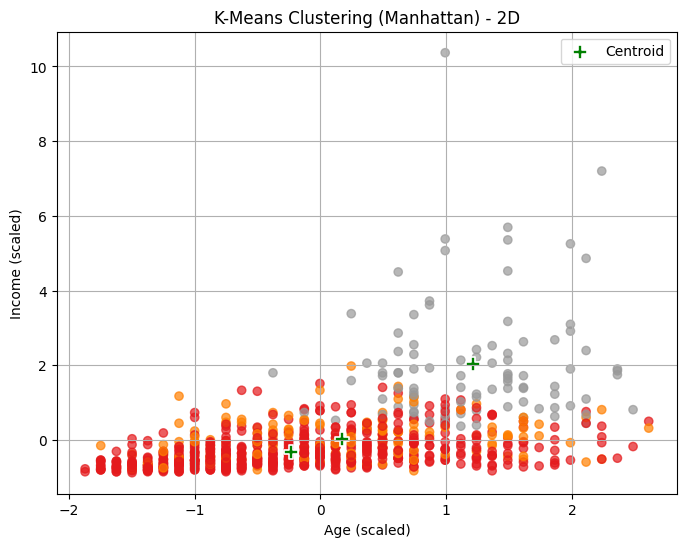

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 3], c=labels_manhattan, cmap='Set1', alpha=0.7)
plt.scatter(centroids_manhattan[:, 0], centroids_manhattan[:, 3], 
            s=100, marker='P', c='green', edgecolor='white', linewidths=1.2, label='Centroid')
plt.title("K-Means Clustering (Manhattan) - 2D")
plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")
plt.legend()
plt.grid(True)
plt.show()

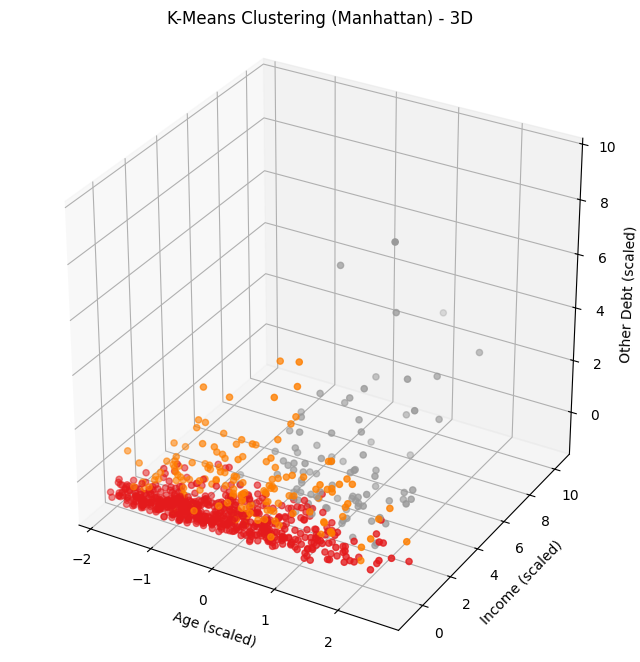

In [28]:
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_scaled[:, 0], X_scaled[:, 3], X_scaled[:, 5], 
           c=labels_manhattan, cmap='Set1')
ax.set_title("K-Means Clustering (Manhattan) - 3D")
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Income (scaled)")
ax.set_zlabel("Other Debt (scaled)")
ax.set_box_aspect([1, 1, 1])
plt.show()

In [27]:
score_man = silhouette_score(X_scaled, labels_manhattan)
print("Silhouette Score (Manhattan):", score_man)

Silhouette Score (Manhattan): 0.2889072058358442


Based on the Silhouette Score, the Manhattan distance produces better-defined clusters in this dataset.
This could be due to the nature of the features or the influence of outliers, which Manhattan distance handles more robustly.